In [6]:
from CRNs import *
import numpy as np
import pickle
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Arial'
import seaborn as sns


## Scans over DAGs

['1_1', '1_2', '1_3', '1_4', '1_5', '1_6', '1_7', '1_8', '1_9', '1_10', '2_1', '2_2', '2_3', '2_4', '2_5', '2_6', '2_7', '2_8', '2_9', '2_10', '3_1', '3_2', '3_3', '3_4', '3_5', '3_6', '3_7', '3_8', '3_9', '3_10', '4_1', '4_2', '4_3', '4_4', '4_5', '4_6', '4_7', '4_8', '4_9', '4_10', '5_1', '5_2', '5_3', '5_4', '5_5', '5_6', '5_7', '5_8', '5_9', '5_10']


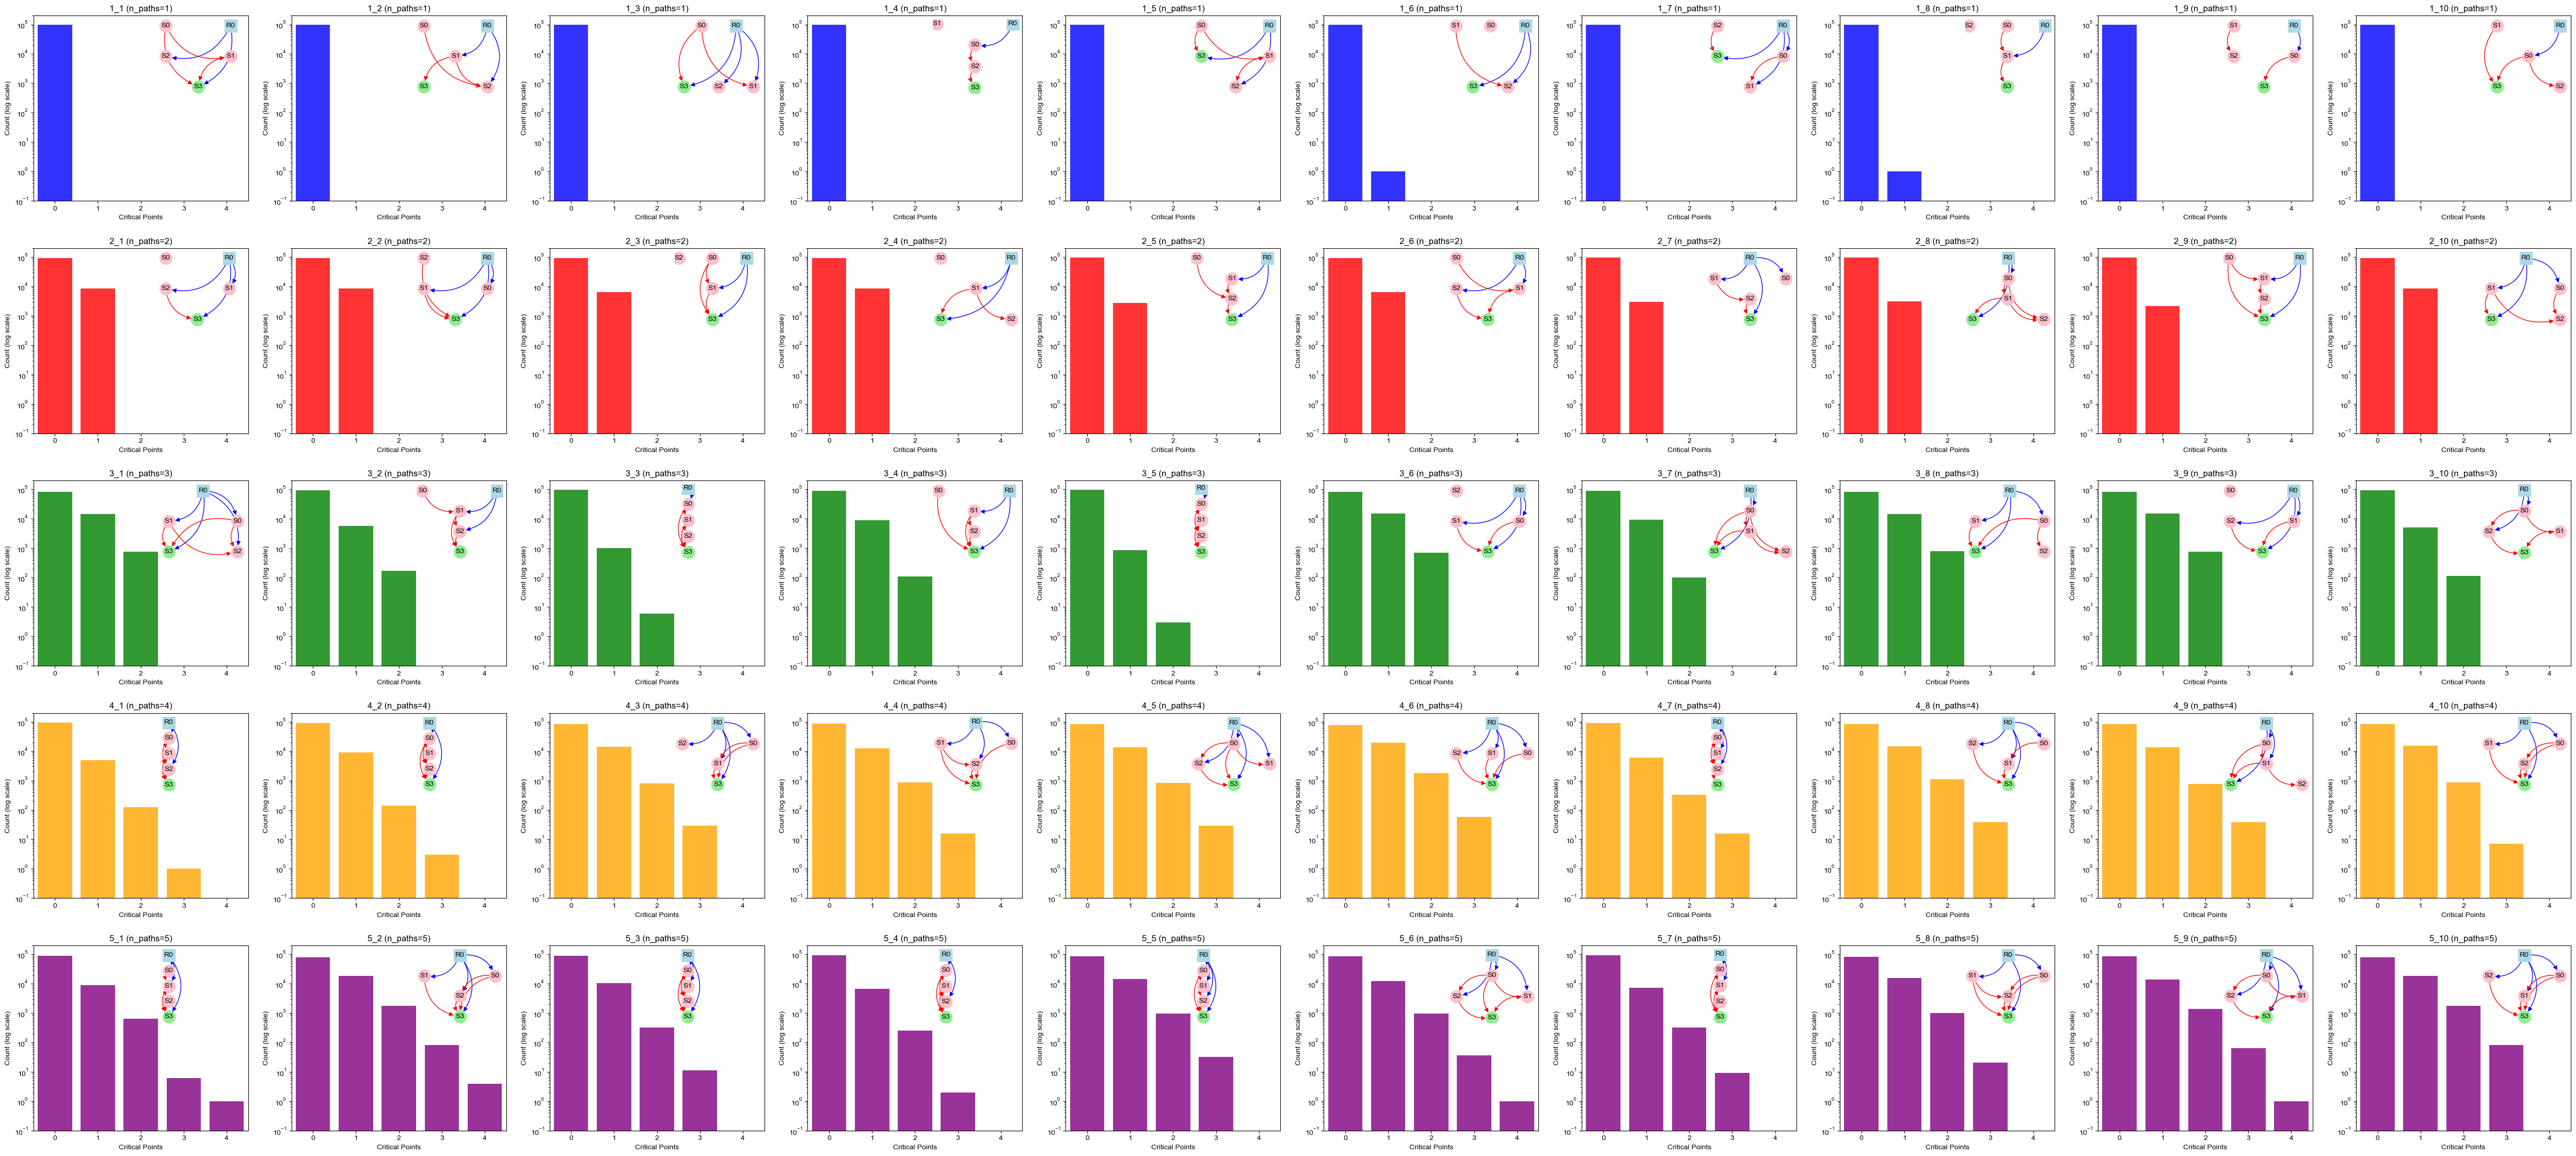

In [2]:
colors = ['blue', 'red', 'green', 'orange', 'purple', 'brown', 'pink', 'gray']  # Color options

# Set up parameters and data
path = "/Users/csfloyd/Dropbox/Projects/GlycanAnalysis/AnalyzedData/dag_n_paths_idx_NS4_biggest_pr0/"
pv_sublist = [str(a) + "_" + str(b) for a in range(1, 6) for b in range(1, 11)]  # 5 rows (a), 3 cols (b)
print(pv_sublist)
pr = 1.0

# Gather axes network data for all pv values
axes_data = []
for pv in pv_sublist:
    file = path + pv + "/critical_points.pkl"
    try:
        with open(file, "rb") as f:
            data = pickle.load(f)
        network_data = data['network_data']
        input_substrates_list = network_data[-1]['input_substrates_list']
        adjacency_matrix = network_data[-1]['adjacency_matrix']
        NR = network_data[-1]['NR']
        NS = network_data[-1]['NS']
        axes_data.append(dict(
            pv=pv,
            adjacency_matrix=adjacency_matrix,
            input_substrates_list=input_substrates_list,
            NR=NR,
            NS=NS
        ))
    except FileNotFoundError:
        print(f"File not found for pv={pv}: {file}")
        axes_data.append(None)
    except Exception as e:
        print(f"Error processing pv={pv}: {e}")
        axes_data.append(None)

valid_axes_data = [d for d in axes_data if d is not None]
num_valid = len(valid_axes_data)

# Predefine axis limits for consistency
critical_points_xlim = (-0.5, 4.5)
critical_points_ylim = (0.1, 2e5)
arc_length_xlim = (1.0, 1.05)
arc_length_ylim = (1, 6e4)
tac_length_xlim = (0, 0.3)
tac_length_ylim = (1, 6e4)
mlp_width_xlim = (0.5, 8.5)
mlp_width_ylim = (1, 6e4)

valid_results_dict = {}
n_paths_dict = {}

if num_valid > 0:
    n_rows, n_cols = 5, 10
    # Validate shape
    assert len(valid_axes_data) == n_rows * n_cols, "pv_sublist must have 15 entries for 5x3 grid."
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4.5*n_rows))
    if n_rows == 1 and n_cols == 1:
        axes = np.array([[axes]])
    elif n_rows == 1 or n_cols == 1:
        axes = axes.reshape((n_rows, n_cols))
    axes = np.atleast_2d(axes)

    for idx, (d, pv) in enumerate(zip(valid_axes_data, pv_sublist)):
        row = idx // n_cols
        col = idx % n_cols
        ax_hist = axes[row, col]
        file = path + pv + "/critical_points.pkl"
        try:
            with open(file, "rb") as f:
                data = pickle.load(f)
            network_data = data['network_data']
            results_list = [network_data[j]['result_value'][0] for j in range(len(network_data) - 1)]
            valid_results = [x for x in results_list if x is not None]
            valid_results_dict[pv] = valid_results
            n_paths_list = [network_data[j]['n_paths'] for j in range(len(network_data) - 1)]
            n_paths_dict[pv] = n_paths_list
            # Print n_paths stats
            # print(f"pv={pv}: max n_paths={max(n_paths_list)}, min n_paths={min(n_paths_list)}")
            if valid_results:
                bins = range(min(valid_results), max(valid_results) + 2, 1)
                color = colors[row % len(colors)]
                ax_hist.hist(valid_results, bins=bins, align='left', rwidth=0.8,
                             color=color, alpha=0.8)
            ax_hist.set_yscale('log')
            ax_hist.set_title(f'{pv} (n_paths={max(n_paths_list)})', fontsize=12)
            ax_hist.set_xlabel('Critical Points')
            ax_hist.set_ylabel('Count (log scale)')
            ax_hist.set_xlim(critical_points_xlim)
            ax_hist.set_ylim(critical_points_ylim)
        except FileNotFoundError:
            print(f"File not found for pv={pv}: {file}")
            ax_hist.set_title(f"{pv}: Missing data")
        except Exception as e:
            print(f"Error processing pv={pv}: {e}")
            ax_hist.set_title(f"{pv}: Data error")

        # Inset axes for network drawing
        try:
            # smaller inset at top right, no border
            from mpl_toolkits.axes_grid1.inset_locator import inset_axes
            ax_inset = inset_axes(ax_hist, width="40%", height="40%", loc='upper right', borderpad=0.5)
            # Remove black border around inset
            for spine in ax_inset.spines.values():
                spine.set_visible(False)
            visualize_dag_signaling_network(
                d['adjacency_matrix'],
                d['input_substrates_list'],
                d['NR'],
                d['NS'],
                node_size=300,
                arrow_size=12,
                font_size=10,
                ax=ax_inset
            )
            ax_inset.set_xticks([])
            ax_inset.set_yticks([])
            ax_inset.set_xlabel("")
            ax_inset.set_ylabel("")
            ax_inset.set_title("", fontsize=8)
        except Exception as e:
            print(f"error in network inset for {pv}: {e}")

    plt.tight_layout(h_pad=2.3, w_pad=2.1)
    plt.show()

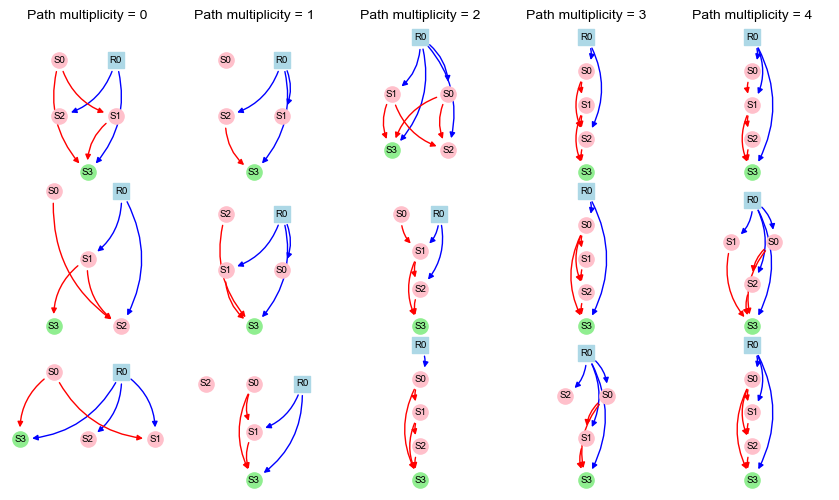

In [17]:
plt.rcParams['font.family'] = 'Arial'
fs = 10
plt.rcParams['font.size'] = fs

# Set up parameters and data: Grid is 3 rows (b from 1 to 3) x 5 cols (a from 1 to 5), a varies across columns, b across rows
path = "/Users/csfloyd/Dropbox/Projects/GlycanAnalysis/AnalyzedData/dag_n_paths_idx_NS4_biggest_pr0/"
n_rows, n_cols = 3, 5
b_range = range(1, n_rows + 1)   # 1 through 3
a_range = range(1, n_cols + 1)   # 1 through 5

# Build pv_sublist in row-major order with b along rows, a along columns
pv_sublist = [f"{a}_{b}" for b in b_range for a in a_range]
pr = 1.0

axes_data = []
for pv in pv_sublist:
    file = path + pv + "/critical_points.pkl"
    try:
        with open(file, "rb") as f:
            data = pickle.load(f)
        network_data = data['network_data']
        axes_data.append(dict(
            pv=pv,
            adjacency_matrix=network_data[-1]['adjacency_matrix'],
            input_substrates_list=network_data[-1]['input_substrates_list'],
            NR=network_data[-1]['NR'],
            NS=network_data[-1]['NS']
        ))
    except Exception as e:
        print(f"Error for pv={pv}: {e}")
        axes_data.append(None)

valid_axes_data = [d for d in axes_data if d is not None]

small_axes_data = valid_axes_data[:n_rows * n_cols]
small_pv_sublist = pv_sublist[:n_rows * n_cols]

if small_axes_data:
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(1.7*n_cols, 1.7*n_rows))
    axes = np.atleast_2d(axes)

    for idx, (d, pv) in enumerate(zip(small_axes_data, small_pv_sublist)):
        row = idx // n_cols
        col = idx % n_cols
        ax = axes[row, col]
        try:
            visualize_dag_signaling_network(
                d['adjacency_matrix'],
                d['input_substrates_list'],
                d['NR'],
                d['NS'],
                node_size=120,
                arrow_size=8,
                font_size=7,
                rad=0.3,
                ax=ax
            )
            ax.set_xticks([])
            ax.set_yticks([])
            ax.set_xlabel("")
            ax.set_ylabel("")
            if row == 0:
                ax.set_title(f'Path multiplicity = {col}', fontsize=fs)
            for spine in ax.spines.values():
                spine.set_visible(False)
        except Exception as e:
            print(f"Network error for {pv}: {e}")
            ax.set_title(f"{pv}: Data error")
    plt.tight_layout(h_pad=0.0, w_pad=0.8)
    fig.savefig(f"/Users/csfloyd/Dropbox/Projects/GlycanAnalysis/Figures/nonrecurrent_network_grid.png", dpi=300)
    plt.show()

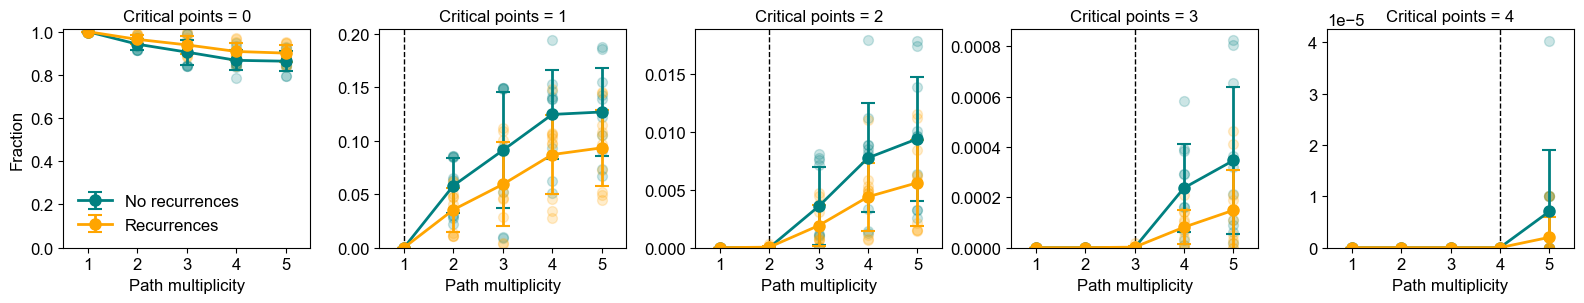

In [5]:
from collections import Counter
import numpy as np
import pickle
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Arial'
fs = 12
plt.rcParams['font.size'] = fs

# Set up parameters and data
base_path = "/Users/csfloyd/Dropbox/Projects/GlycanAnalysis/AnalyzedData/"
paths = {
    'pr0': base_path + "dag_n_paths_idx_NS4_biggest_pr0/",
    'pr1': base_path + "dag_n_paths_idx_NS4_biggest_pr1/"
}

n_samps = 10
n_paths = 5

# Collect data for both paths
all_result_values = set()
prob_data = {}  # prob_data[path_key][n_path][n_samp] = {result_value: probability}

for path_key, path in paths.items():
    prob_data[path_key] = {}
    for n_path in range(1, n_paths + 1):
        prob_data[path_key][n_path] = {}
        for n_samp in range(1, n_samps + 1):
            pv = f"{n_path}_{n_samp}"
            file = path + pv + "/critical_points.pkl"
            try:
                with open(file, "rb") as f:
                    data = pickle.load(f)
                network_data = data['network_data']
                results_list = [network_data[j]['result_value'][0] for j in range(len(network_data) - 1)]
                
                # Filter out None values from results_list
                results_list = [x for x in results_list if x is not None]
                
                results_counts = Counter(results_list)
                total_count = len(results_list)
                if total_count > 0:
                    results_histogram = {value: count / total_count for value, count in results_counts.items()}
                else:
                    results_histogram = {}
                
                prob_data[path_key][n_path][n_samp] = results_histogram
                all_result_values.update(results_histogram.keys())
                
            except FileNotFoundError:
                print(f"File not found for {path_key}, pv={pv}: {file}")
                prob_data[path_key][n_path][n_samp] = {}
            except Exception as e:
                print(f"Error processing {path_key}, pv={pv}: {e}")
                prob_data[path_key][n_path][n_samp] = {}

# Sort result values for consistent ordering
all_result_values = sorted(all_result_values)

# Define colors for each path
colors = {'pr0': '#1f77b4', 'pr1': '#d62728'}  # Blue for pr0, Red for pr1
colors = {'pr0': 'teal', 'pr1': 'orange'}
offsets = {'pr0': 0, 'pr1': 0}  # Slight x-offset to avoid overlapping
labels = {'pr0': 'No recurrences', 'pr1': 'Recurrences'}

# Create a separate plot for each result value
n_plots = len(all_result_values)
fig_fac = 0.8
fig, axes = plt.subplots(1, n_plots, figsize=(fig_fac * 4 * n_plots, fig_fac * 4))
if n_plots == 1:
    axes = [axes]

ind = 0
for ax, result_val in zip(axes, all_result_values):
    x_vals = list(range(1, n_paths + 1))
    
    for path_key in paths.keys():
        means = []
        stds = []
        all_x_scatter = []
        all_y_scatter = []
        
        for n_path in x_vals:
            # Collect probabilities for this result_val across all n_samps
            probs = []
            for n_samp in range(1, n_samps + 1):
                if n_samp in prob_data[path_key][n_path]:
                    prob = prob_data[path_key][n_path][n_samp].get(result_val, 0.0)
                    probs.append(prob)
                    # Store raw data points for scatter
                    all_x_scatter.append(n_path + offsets[path_key])
                    all_y_scatter.append(prob)
            
            if probs:
                means.append(np.mean(probs))
                stds.append(np.std(probs))
            else:
                means.append(0)
                stds.append(0)
        
        # Plot raw scatter points
        ax.scatter(all_x_scatter, all_y_scatter, color=colors[path_key], alpha=0.2, 
                   s=50, zorder=1)
        
        # Plot with error bars (with slight x-offset)
        x_offset = [x + offsets[path_key] for x in x_vals]
        ax.errorbar(x_offset, means, yerr=stds, fmt='o-', capsize=5, capthick=1.5, 
                    markersize=8, linewidth=2, color=colors[path_key], label=labels[path_key], zorder=2)
    
    # Add vertical dashed black lines at integer x-coordinates (including zero)
    #for xline in range(0, n_paths + 2):  # one beyond rightmost to include n_paths+1
    ax.axvline(x=ind, color='black', linestyle='dashed', linewidth=1, alpha=1, zorder=-5)
    ind += 1

    ax.set_xlabel('Path multiplicity', fontsize=fs)
    if result_val == 0:
        ax.set_ylabel('Fraction', fontsize=fs)
    ax.set_title(f'Critical points = {result_val}', fontsize=fs)
    ax.set_xticks(x_vals)
    ax.set_xlim(0.5, n_paths + 0.5)
    ax.set_ylim(0, None)
    #ax.grid(True, alpha=0.3)
    if result_val == 0:
        ax.legend(frameon=False, fontsize=fs)

plt.tight_layout(w_pad=0.5)
fig.savefig(f"/Users/csfloyd/Dropbox/Projects/GlycanAnalysis/Figures/Critical_points_prob.png", dpi=300)
plt.show()

## Trainings scans

In [37]:
import pickle
import numpy as np
import matplotlib.pyplot as plt

# Set up parameters and data
#path = "/Users/csfloyd/Dropbox/Projects/GlycanAnalysis/Dirs/Training/NR_width_seed_big2/"
path = "/Users/csfloyd/Dropbox/Projects/GlycanAnalysis/Dirs/Training/NR_pf_seed_big_pr0/"

var1_list = [1, 2, 3, 4, 5]  # e.g., proj_dim / NR
var2_list = [1, 2, 3, 4, 5]  # e.g., hidden_dim
var2_list = [0.2, 0.4, 0.6, 0.8, 1.0]  # e.g., hidden_dim
var3_list = [1, 2, 3, 4, 5]  # seeds (will average over these)

# Store results: var1 x var2, averaged over var3
accuracy_matrix = np.zeros((len(var1_list), len(var2_list)))
loss_matrix = np.zeros((len(var1_list), len(var2_list)))

for i, var1 in enumerate(var1_list):
    for j, var2 in enumerate(var2_list):
        accuracies = []
        losses = []
        
        for var3 in var3_list:
            file = path + f"{var1}_{var2}_{var3}/training_results.pkl"
            try:
                with open(file, "rb") as f:
                    data = pickle.load(f)
                
                history = data['history']
                
                # Get final accuracy (average of last 100 batches)
                if hasattr(history, 'get_recent_avg'):
                    final_acc = history.get_recent_avg('accuracy', window=100)
                    final_loss = history.get_recent_avg('loss', window=100)
                else:
                    # Fallback if history is a dict
                    final_acc = np.mean(history.accuracy_history[-100:])
                    final_loss = np.mean(history.loss_history[-100:])
                
                accuracies.append(final_acc)
                losses.append(final_loss)
                
            except FileNotFoundError:
                print(f"File not found: {file}")
            except Exception as e:
                print(f"Error loading {file}: {e}")
        
        # Average over seeds
        if accuracies:
            accuracy_matrix[i, j] = np.mean(accuracies)
            loss_matrix[i, j] = np.mean(losses)
        else:
            accuracy_matrix[i, j] = np.nan
            loss_matrix[i, j] = np.nan


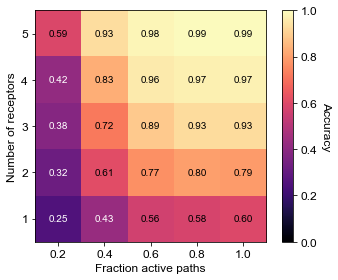

In [39]:
# Plot heatmap
import pickle
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Arial'

import numpy as np
fs = 12
fig, ax = plt.subplots(1, 1, figsize=(5, 4))

# Accuracy heatmap
im1 = ax.imshow(accuracy_matrix, cmap='magma', vmin=0.0, vmax=1, origin='lower', aspect='equal')
ax.set_xticks(range(len(var2_list)))
ax.set_xticklabels(var2_list, fontsize=fs)
ax.set_yticks(range(len(var1_list)))
ax.set_yticklabels(var1_list, fontsize=fs)
ax.set_xlabel('Fraction active paths', fontsize=fs)
ax.set_ylabel('Number of receptors', fontsize=fs)
#ax.set_box_aspect(1)

cbar = plt.colorbar(im1, ax=ax)
cbar.ax.set_ylabel('Accuracy', rotation=-90, va="bottom", fontsize=fs)
cbar.ax.tick_params(labelsize=fs)

# Add text annotations
for i in range(len(var1_list)):
    for j in range(len(var2_list)):
        val = accuracy_matrix[i, j]
        if not np.isnan(val):
            text_color = 'white' if val < 0.5 else 'black'
            ax.text(j, i, f'{val:.2f}', ha='center', va='center', color=text_color, fontsize=fs-2)



plt.tight_layout(w_pad=0.5)
fig.patch.set_facecolor('white')
fig.savefig(f"/Users/csfloyd/Dropbox/Projects/GlycanAnalysis/Figures/Receptor_pf_accuracy.png", dpi=300)
plt.show()

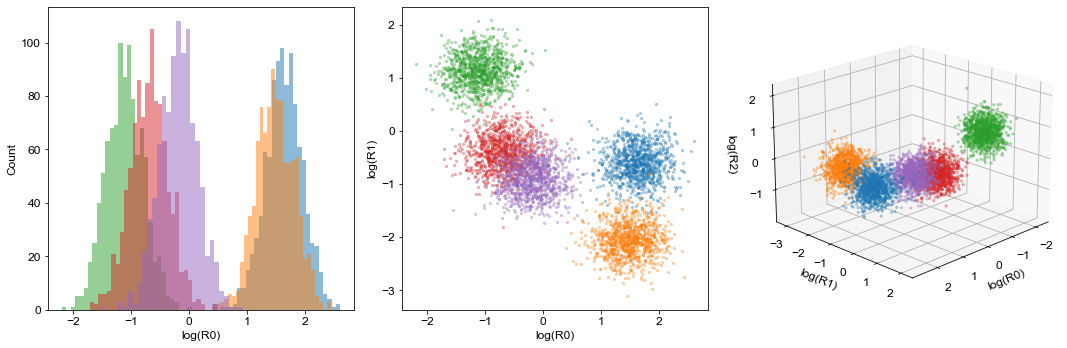

In [61]:
# Choose specific values
import pickle
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Arial'

var1, var2, var3 = 5, 5, 1  # Example: proj_dim=2, hidden_dim=3, seed=1

path = "/Users/csfloyd/Dropbox/Projects/GlycanAnalysis/Dirs/Training/NR_width_seed_big/"
file = path + f"{var1}_{var2}_{var3}/training_results.pkl"

with open(file, "rb") as f:
    data = pickle.load(f)

xlabel = 'log(R0)'
ylabel = 'log(R1)'
zlabel = 'log(R2)'

# Regenerate data from saved parameters
log_means = data['log_means']
n_classes = data['n_classes']
input_dim = data['input_dim']
log_variance = data['log_variance'] / input_dim  # per-dim variance
proj_dim = data['proj_dim']

_, data_list = generate_lognormal_mixture(
    n_classes=n_classes,
    n_samples_per_class=1000,  # Fewer for plotting
    input_dim=input_dim,
    log_means=log_means,
    log_variances=[log_variance] * n_classes,
    random_state=42
)
data_list = project_data_list(data_list, d=proj_dim)

# Plot 3-panel figure with log-scaled data
fig = plt.figure(figsize=(15, 5))

# Panel 1: 1D histogram (log scale)
ax1 = fig.add_subplot(1, 3, 1)
for c, class_data in enumerate(data_list):
    arr = np.vstack(class_data)
    log_data = np.log(arr[:, 0])
    ax1.hist(log_data, bins=30, alpha=0.5, label=f'Class {c}')
ax1.set_xlabel(xlabel)
ax1.set_ylabel('Count')
#ax1.set_title('1D Projection (Log Scale)')
#ax1.legend()

# Panel 2: 2D scatter (log scale)
ax2 = fig.add_subplot(1, 3, 2)
for c, class_data in enumerate(data_list):
    arr = np.vstack(class_data)
    ax2.scatter(np.log(arr[:, 0]), np.log(arr[:, 1]), alpha=0.3, s=5, label=f'Class {c}')
# Plot centers
# for i, lm in enumerate(log_means):
#     ax2.scatter(lm[0], lm[1], marker='x', s=100, c='black', linewidths=2)
ax2.set_xlabel(xlabel)
ax2.set_ylabel(ylabel)
#ax2.set_title('2D Projection (Log Scale)')
#ax2.legend()

# Panel 3: 3D scatter (log scale)
ax3 = fig.add_subplot(1, 3, 3, projection='3d')
for c, class_data in enumerate(data_list):
    arr = np.vstack(class_data)
    ax3.scatter(np.log(arr[:, 0]), np.log(arr[:, 1]), np.log(arr[:, 2]), alpha=0.3, s=5, label=f'Class {c}')
# Plot centers
for i, lm in enumerate(log_means):
    ax3.scatter(lm[0], lm[1], lm[2], marker='x', s=100, c='black', linewidths=2)
ax3.set_xlabel(xlabel)
ax3.set_ylabel(ylabel)
ax3.set_zlabel(zlabel, rotation=0)
#ax3.set_title('3D Projection (Log Scale)')
#ax3.set_box_aspect(1)  # or try ax3.set_box_aspect([1, 1, 1])

ax3.dist = 9
ax3.view_init(elev=20, azim=45)  # Change viewing angle
#ax3.legend()

# Adjust 3D plot position to move it more to the left

#ax3.set_position([pos.x0 + 0.3, pos.y0, pos.width, pos.height])

plt.tight_layout(h_pad=-0.2)
fig.savefig(f"/Users/csfloyd/Dropbox/Projects/GlycanAnalysis/Figures/projected_data.png", dpi=300)
plt.show()

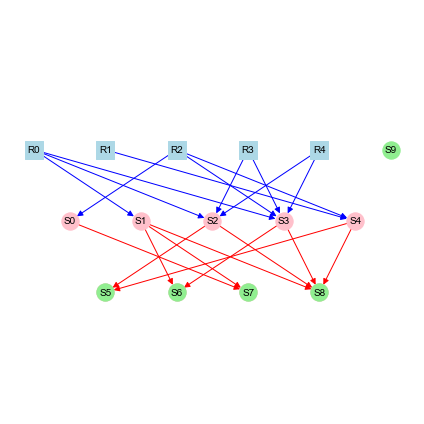

In [47]:
path = "/Users/csfloyd/Dropbox/Projects/GlycanAnalysis/Dirs/Training/NR_width_seed_big/"
path = "/Users/csfloyd/Dropbox/Projects/GlycanAnalysis/Dirs/Training/NR_pf_seed_big_pr0/"
path = "/Users/csfloyd/Dropbox/Projects/GlycanAnalysis/Dirs/Training/tasks_pf_seed_big/"


var1 = 5
var2 = 0.4
var3 = 3
file = path + f"{var1}_{var2}_{var3}/training_results.pkl"

with open(file, "rb") as f:
    data = pickle.load(f)
                
                    
fig = visualize_dag_signaling_network(
    data['adjacency_matrix'],
    data['input_substrates_list'],
    data['NR'],
    data['NS'],
    node_size=300,
    arrow_size=12,
    font_size=10,
    rad = 0,
    num_outputs = 5,
    flip_horizontal = True
)

fig.patch.set_facecolor('white')
plt.tight_layout(w_pad=0.5)
#fig.savefig(f"/Users/csfloyd/Dropbox/Projects/GlycanAnalysis/Figures/pf0p4_layered_network.png", dpi=300)
plt.show()

In [45]:
import pickle
import numpy as np
import matplotlib.pyplot as plt

# Set up parameters and data
path = "/Users/csfloyd/Dropbox/Projects/GlycanAnalysis/Dirs/Training/tasks_pf_seed_big/"

var1_list = [1, 2, 3, 4, 5]  # e.g., proj_dim / NR
var2_list = [1, 2, 3, 4, 5]  # e.g., hidden_dim
var2_list = [0.2, 0.4, 0.6, 0.8, 1.0]  # e.g., hidden_dim
var3_list = [1, 2, 3, 4, 5]  # seeds (will average over these)

# Store results: var1 x var2, averaged over var3
accuracy_matrix = np.zeros((len(var1_list), len(var2_list)))
loss_matrix = np.zeros((len(var1_list), len(var2_list)))

for i, var1 in enumerate(var1_list):
    for j, var2 in enumerate(var2_list):
        accuracies = []
        losses = []
        
        for var3 in var3_list:
            file = path + f"{var1}_{var2}_{var3}/training_results.pkl"
            try:
                with open(file, "rb") as f:
                    data = pickle.load(f)
                
                history = data['history']
                
                # Get final accuracy (average of last 100 batches)
                if hasattr(history, 'get_recent_avg'):
                    final_acc = history.get_recent_avg('accuracy', window=100)
                    final_loss = history.get_recent_avg('loss', window=100)
                else:
                    # Fallback if history is a dict
                    final_acc = np.mean(history.accuracy_history[-100:])
                    final_loss = np.mean(history.loss_history[-100:])
                
                accuracies.append(final_acc)
                losses.append(final_loss)
                
            except FileNotFoundError:
                print(f"File not found: {file}")
            except Exception as e:
                print(f"Error loading {file}: {e}")
        
        # Average over seeds
        if accuracies:
            accuracy_matrix[i, j] = np.mean(accuracies)
            loss_matrix[i, j] = np.mean(losses)
        else:
            accuracy_matrix[i, j] = np.nan
            loss_matrix[i, j] = np.nan



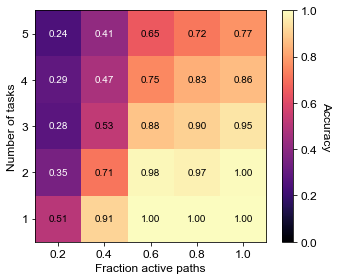

In [48]:
# Plot heatmap
import pickle
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Arial'

import numpy as np
fs = 12
fig, ax = plt.subplots(1, 1, figsize=(5, 4))

# Accuracy heatmap
im1 = ax.imshow(accuracy_matrix, cmap='magma', vmin=0.0, vmax=1, origin='lower')
ax.set_xticks(range(len(var2_list)))
ax.set_xticklabels(var2_list, fontsize=fs)
ax.set_yticks(range(len(var1_list)))
ax.set_yticklabels(var1_list, fontsize=fs)
ax.set_xlabel('Fraction active paths', fontsize=fs)
ax.set_ylabel('Number of tasks', fontsize=fs)

cbar = plt.colorbar(im1, ax=ax)
cbar.ax.set_ylabel('Accuracy', rotation=-90, va="bottom", fontsize=fs)
cbar.ax.tick_params(labelsize=fs)

# Add text annotations
for i in range(len(var1_list)):
    for j in range(len(var2_list)):
        val = accuracy_matrix[i, j]
        if not np.isnan(val):
            text_color = 'white' if val < 0.5 else 'black'
            ax.text(j, i, f'{val:.2f}', ha='center', va='center', color=text_color, fontsize=fs-2)



plt.tight_layout(w_pad=0.5)
fig.savefig(f"/Users/csfloyd/Dropbox/Projects/GlycanAnalysis/Figures/tasks_pf_accuracy.png", dpi=300)
plt.show()

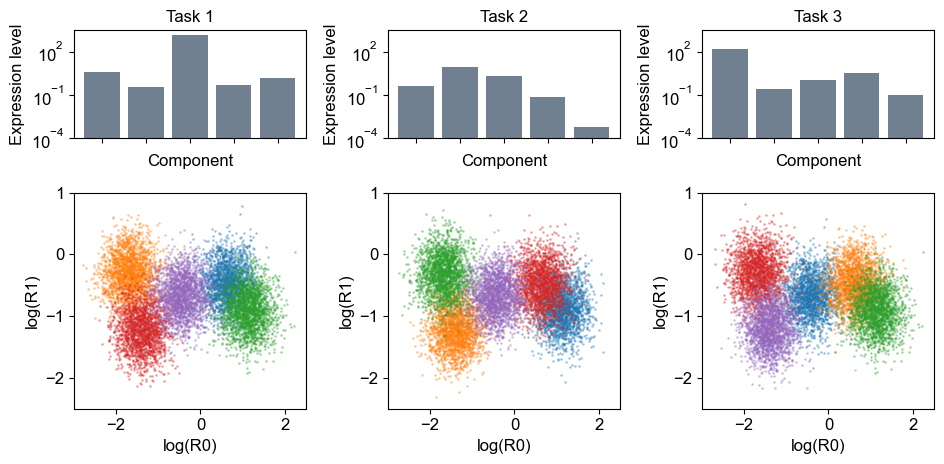

<Figure size 640x480 with 0 Axes>

In [77]:
# ============== VISUALIZE TASK DATA ==============
task_data = data['task_data']
n_tasks = data['n_tasks']
n_classes = data['n_classes']
input_dim = data['input_dim']
proj_dim = data['proj_dim']
log_variance = data['log_variance'] / input_dim  # per-dim variance

task_ids = list(task_data.keys())

n_tasks = 3
fig_fac = 0.8

# For each task, plot l0 barplot above its scatter plot
fig, axes = plt.subplots(2, n_tasks, figsize=(fig_fac * (n_tasks*4), fig_fac * 6), gridspec_kw={'height_ratios': [1.5,3]})

# If only one task, axes shape needs flattening
if n_tasks == 1:
    axes = np.array([[axes[0]], [axes[1]]])

NR = 5
NS = 5
fs = 12

for i, task_id in enumerate(task_ids[:n_tasks]):
    task = task_data[task_id]
    l0 = task['l0'][NR:-NS] if len(task['l0']) > NR+NS else task['l0']
    # Bar plot (top row)
    ax_bar = axes[0, i]
    ax_bar.bar(range(len(l0)), l0, color = 'slategray')
    ax_bar.set_xlabel('Component', fontsize=fs)
    ax_bar.set_ylabel('Expression level', fontsize=fs)
    ax_bar.set_yscale('log')
    ax_bar.set_title(f'Task {i+1}', fontsize=fs)
    ax_bar.tick_params(axis='both', labelsize=fs)
    ax_bar.set_xticks(range(0, len(l0), 1))
    ax_bar.set_xticklabels([])
    #ax_bar.set_ylim(bottom=max(np.min(l0[l0>0])*0.8 if np.any(l0>0) else 0.1, 1e-6))
    ax_bar.set_ylim(0.0001, 3000)
    
    # Scatter plot (bottom row)
    log_means = task['log_means']

    # Regenerate data from log_means
    _, data_list = generate_lognormal_mixture(
        n_classes=n_classes,
        n_samples_per_class=2000,
        input_dim=input_dim,
        log_means=log_means,
        log_variances=[log_variance] * n_classes,
        random_state=42
    )
    data_list = project_data_list(data_list, d=proj_dim)

    ax_scatter = axes[1, i]
    for c, class_data in enumerate(data_list):
        arr = np.vstack(class_data)
        ax_scatter.scatter(np.log(arr[:, 0]), np.log(arr[:, 1]), alpha=0.3, s=1, label=f'Class {c}')
        #ax_scatter.scatter(arr[:, 0], arr[:, 1], alpha=0.3, s=1, label=f'Class {c}')

    ax_scatter.set_xlabel('log(R0)', fontsize=fs)
    ax_scatter.set_ylabel('log(R1)', fontsize=fs)
    #ax_scatter.set_title(f'Task {i+1}', fontsize=fs)
    ax_scatter.set_xlim(-3, 2.5)
    ax_scatter.set_ylim(-2.5, 1)
    ax_scatter.tick_params(axis='both', labelsize=fs)

plt.tight_layout()
plt.show()

plt.tight_layout(w_pad=0.5)
fig.savefig(f"/Users/csfloyd/Dropbox/Projects/GlycanAnalysis/Figures/Task_definitions.png", dpi=300)
plt.show()